# 12: SA3D vs Custom Pipeline Comparison

This notebook performs a quantitative comparison between two 3D object isolation
pipelines applied to Meta Project Aria egocentric recordings from the Digital Twin
Catalog (DTC) dataset:

- **Custom Pipeline (SAM2 + Nerfstudio):** 2D segmentation masks are generated via
  SAM2 video propagation from a single point prompt, then projected onto a Nerfstudio
  (nerfacto) 3D mesh reconstruction using majority voting to isolate the target object.

- **SA3D (Segment Anything in 3D):** A DVGOv2-based NeRF is trained on the scene,
  then SA3D propagates a 2D SAM prompt into a 3D voxel segmentation mask. The isolated
  object is extracted via marching cubes on the density grid filtered by the
  segmentation mask.

Both reconstructions are aligned to the DTC ground truth mesh using PCA + ICP
registration and evaluated with Chamfer distance, F-Score (1 cm), and volumetric IoU.


In [1]:
import json
import pandas as pd
import numpy as np
import open3d as o3d
from pathlib import Path

from aria_pylib.utils import find_points_file

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Path Configuration
Define the input data directories and the output paths for the exported `.ply` files.

In [ ]:
SCENE_NAME = "dragon"

# Input base directories
base_dir = Path(r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data")
dtc_dir = base_dir / "dtc" / SCENE_NAME
slam_dir = dtc_dir / "slam"

# Resolve input file paths
points_csv_path = find_points_file(str(slam_dir))
model_glb_path = dtc_dir / "3d-asset-manifold.glb"
pose_json_path = dtc_dir / "groundtruth" / "object_pose.json"

# Define output file paths
output_dir = base_dir / "outputs" / "alignment" / "dtc" / SCENE_NAME
output_dir.mkdir(parents=True, exist_ok=True)
out_scene_ply = output_dir / "scene_slam_points.ply"
out_object_ply = output_dir / "aligned_object_mesh.ply"

assert model_glb_path.exists(), f"Model not found at {model_glb_path}"
assert pose_json_path.exists(), f"Pose JSON not found at {pose_json_path}"

## Point Cloud Processing and Export
Load the compressed CSV generated by the ADT MPS system. Extract the world coordinates dynamically, cast them to an Open3D PointCloud structure, and serialize the data to disk.

In [3]:
print(f"Loading SLAM point cloud from {Path(points_csv_path).name}...")

# Read the compressed CSV data
df_points = pd.read_csv(points_csv_path)

# Dynamically resolve coordinate column names
x_col = next(col for col in df_points.columns if col.endswith('x_world') or col == 'x')
y_col = next(col for col in df_points.columns if col.endswith('y_world') or col == 'y')
z_col = next(col for col in df_points.columns if col.endswith('z_world') or col == 'z')

# Extract coordinates
xyz = df_points[[x_col, y_col, z_col]].to_numpy(dtype=np.float64)

# Create and save the Open3D PointCloud
scene_pcd = o3d.geometry.PointCloud()
scene_pcd.points = o3d.utility.Vector3dVector(xyz)

o3d.io.write_point_cloud(str(out_scene_ply), scene_pcd)
print(f"Scene point cloud exported to: {out_scene_ply}")

Loading SLAM point cloud from semidense_points.csv.gz...
Scene point cloud exported to: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\alignment\dtc\dragon\scene_slam_points.ply


## Ground Truth Asset Spatial Projection
Load the base `.glb` mesh. Parse the `T_world_object` 4x4 matrix from the JSON metadata and apply the homogeneous transformation to the object's vertices. Finally, export the correctly positioned target mesh to disk.

In [4]:
print(f"Loading object 3D model from {model_glb_path.name}...")
object_mesh = o3d.io.read_triangle_mesh(str(model_glb_path))

# Parse pose metadata
with open(pose_json_path, 'r') as f:
    pose_data = json.load(f)

# Extract and cast the 4x4 transformation matrix
matrix_list = pose_data['mesh']['T_world_object']
T_world_object = np.array(matrix_list, dtype=np.float64)

# Apply spatial transformation to the mesh vertices
object_mesh.transform(T_world_object)

# Export the aligned target mesh
o3d.io.write_triangle_mesh(str(out_object_ply), object_mesh)
print(f"Aligned object mesh exported to: {out_object_ply}")

Loading object 3D model from 3d-asset-manifold.glb...
Aligned object mesh exported to: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\alignment\dtc\dragon\aligned_object_mesh.ply


# RGB Frame Extraction
This module connects to the Project Aria VRS recording, identifies the primary RGB camera stream, and extracts the raw frames. The extracted JPEG images will serve as the core visual input for the Segment Anything 2 (SAM 2) spatial segmentation phase.

In [5]:
# Import the VRS data provider and the local pipeline loader
from projectaria_tools.core import data_provider
from aria_pylib.loaders import extract_frames

## I/O Configuration
Define the input path for the VRS binary file and the target output directory for the extracted image sequence.

In [6]:
vrs_path = dtc_dir / "recording.vrs"
out_images_dir = base_dir / "outputs" / "segmentation" / "dtc" / SCENE_NAME / "images"

# Ensure the output directory exists
out_images_dir.mkdir(parents=True, exist_ok=True)

assert vrs_path.exists(), f"VRS recording not found at {vrs_path}"

## Data Provider Initialization
Initialize the native Project Aria VRS data provider and resolve the explicit stream ID for the front-facing RGB camera (`camera-rgb`).

In [7]:
print("Initializing VRS data provider...")
provider = data_provider.create_vrs_data_provider(str(vrs_path))

# Resolve the target RGB stream ID
rgb_stream_id = provider.get_stream_id_from_label("camera-rgb")
print(f"Target RGB Stream ID resolved: {rgb_stream_id}")

# Query the total number of frames embedded in the stream
num_total_frames = provider.get_num_data(rgb_stream_id)
print(f"Total available RGB frames in VRS: {num_total_frames}")

Initializing VRS data provider...
Target RGB Stream ID resolved: 214-1
Total available RGB frames in VRS: 382


## Frame Extraction, Downscaling, and Distortion Cropping
The RGB sequence is extracted at full temporal resolution (stride 1). To optimize VRAM during SAM 2 inference, a spatial downscale factor of 4 is applied. Subsequently, a 15% center-crop is performed on the scaled images to remove the severe radial distortion inherent to Project Aria wide-angle lenses, ensuring stable tracking.

In [8]:
import shutil
from PIL import Image
from aria_pylib.loaders import extract_rgb_frame, _numpy_to_pil_image
from aria_pylib.preprocessing import apply_crop

# Define parameters
SUBSAMPLE_STRIDE = 1 
JPEG_QUALITY = 100
SCALE_FACTOR = 4

# Clean and setup downscale directory
out_images_4_dir = base_dir / "outputs" / "segmentation" / "dtc" / SCENE_NAME / "images_4"
if out_images_4_dir.exists():
    shutil.rmtree(out_images_4_dir)
out_images_4_dir.mkdir(parents=True, exist_ok=True)

print(f"Extracting and scaling frames (1/{SCALE_FACTOR}) to '{out_images_4_dir.name}'...")

num_total_frames = provider.get_num_data(rgb_stream_id)
indices = list(range(0, num_total_frames, SUBSAMPLE_STRIDE))
n_saved = 0

# Custom extraction loop for resizing
for out_idx, vrs_idx in enumerate(indices):
    frame_arr = extract_rgb_frame(provider, rgb_stream_id, vrs_idx)
    pil_img = _numpy_to_pil_image(frame_arr)
    
    # Downscale
    w, h = pil_img.size
    pil_img_scaled = pil_img.resize(
        (w // SCALE_FACTOR, h // SCALE_FACTOR), 
        Image.Resampling.LANCZOS
    )
    
    pil_img_scaled.save(out_images_4_dir / f"{out_idx:06d}.jpg", quality=JPEG_QUALITY)
    n_saved += 1

# Apply Radial Distortion Crop (15%)
cropped_dir = base_dir / "outputs" / "segmentation" / "dtc" / SCENE_NAME / "images_4_cropped"
if cropped_dir.exists():
    shutil.rmtree(cropped_dir)

print(f"Applying 15% center-crop to mitigate fisheye distortion...")
n_cropped = apply_crop(
    input_dir=str(out_images_4_dir),
    output_dir=str(cropped_dir),
    extension=".jpg",
    crop_percent=0.15
)
print(f"Extraction, Scaling and Crop complete. {n_cropped} frames ready for SAM 2.")

# Update the target image directory for SAM 2 and Visualization
out_images_dir = cropped_dir

Extracting and scaling frames (1/4) to 'images_4'...
Applying 15% center-crop to mitigate fisheye distortion...
Extraction, Scaling and Crop complete. 382 frames ready for SAM 2.


# Manual Point Prompting in SAM 2
This module initializes the SAM 2 video predictor to perform target object isolation. A deterministic manual point prompt is provided to establish the baseline propagation performance of the foundation model across the ADT egocentric recording.

In [9]:
import os
import torch
import numpy as np
from pathlib import Path

# Import the segmentation utilities from the local pipeline
from aria_pylib.segmentation import run_single_prompt, export_masks

from sam2.build_sam import build_sam2_video_predictor

## SAM 2 Predictor Initialization
Load the Segment Anything 2 model weights into VRAM and initialize the video inference state using the newly generated directory of cropped and downscaled frames.

In [10]:
import torch

# Placeholder for SAM 2 imports - adjust based on your specific SAM 2 installation
from sam2.build_sam import build_sam2_video_predictor

# Setup device and data paths
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

sam2_checkpoint = r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\checkpoints\sam2_hiera_large.pt"
model_cfg = "sam2_hiera_l.yaml"

# Initialize the predictor
predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

# Initialize the video state directly from the cropped images directory
inference_state = predictor.init_state(
    video_path=str(out_images_dir),
    offload_video_to_cpu=True,
    offload_state_to_cpu=True,
)

Using device: cuda


frame loading (JPEG): 100%|██████████| 382/382 [00:10<00:00, 35.35it/s]


## Manual Prompt Configuration and Visual Check
Define the initialization prompt coordinates. A spatial graph with a pixel grid is plotted over the target frame to visually verify the prompt placement.

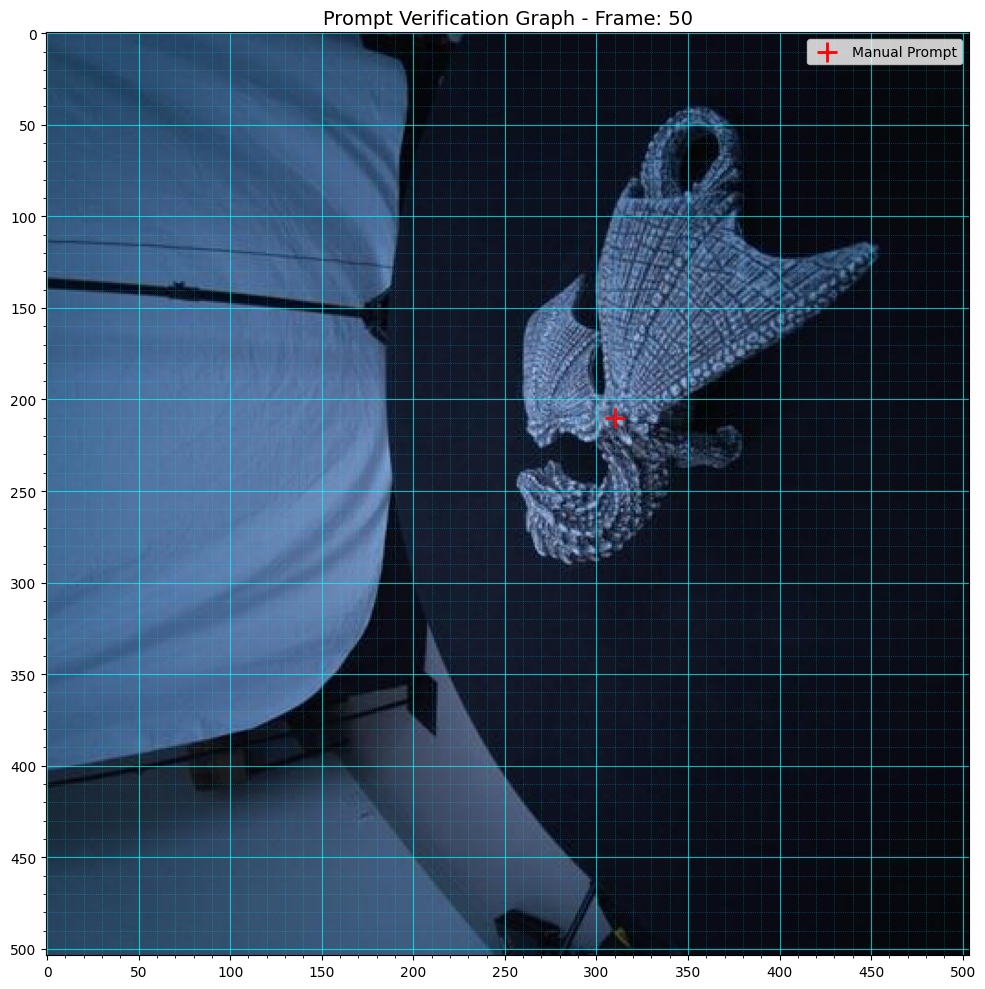

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.ticker import MultipleLocator

TARGET_FRAME_IDX = 50
TARGET_COORDS = [310.0, 210.0] 

manual_prompt = {
    "object_id": 1,
    "init_frame_idx": TARGET_FRAME_IDX,
    "point_coords": TARGET_COORDS,
    "point_labels": [1] 
}

# Visual check plotting
frame_path = out_images_dir / f"{TARGET_FRAME_IDX:06d}.jpg"

if frame_path.exists():
    img = Image.open(frame_path)
    
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(img)
    
    # Plot the chosen prompt as a graph marker
    ax.scatter(TARGET_COORDS[0], TARGET_COORDS[1], color='red', marker='+', s=200, linewidths=2, label='Manual Prompt')
    
    # Configure pixel grid for precise spatial reading
    ax.xaxis.set_major_locator(MultipleLocator(50))
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(50))
    ax.yaxis.set_minor_locator(MultipleLocator(10))
    
    ax.grid(which='major', color='cyan', linestyle='-', linewidth=0.8, alpha=0.7)
    ax.grid(which='minor', color='cyan', linestyle=':', linewidth=0.5, alpha=0.4)
    ax.tick_params(which='both', direction='out', labelsize=10)
    
    ax.set_title(f"Prompt Verification Graph - Frame: {TARGET_FRAME_IDX}", fontsize=14)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
else:
    raise FileNotFoundError(f"Image file not found at {frame_path}. Ensure extraction was successful.")

## Mask Propagation and Export
Execute the bidirectional video propagation using the configured point prompt. The generated binary masks are converted to a multi-label format and exported as palettized PNGs, maintaining label integrity for downstream 3D projection.

In [14]:
import numpy as np
import shutil

from aria_pylib.segmentation import run_single_prompt, export_masks

masks_output_dir = base_dir / "outputs" / "segmentation" / "dtc" / SCENE_NAME / "masks"
if masks_output_dir.exists():
    shutil.rmtree(masks_output_dir)
masks_output_dir.mkdir(parents=True, exist_ok=True)

print("Starting SAM 2 bidirectional propagation...")

object_masks = run_single_prompt(
    predictor=predictor,
    inference_state=inference_state,
    prompt=manual_prompt
)

# Convert the binary masks into a multi-label format
merged_masks = {fi: (mask.astype(np.uint8) * manual_prompt["object_id"]) for fi, mask in object_masks.items()}

# Export the masks to disk
n_exported = export_masks(
    merged_masks=merged_masks,
    output_dir=str(masks_output_dir)
)

print(f"Segmentation complete. Exported {n_exported} masks to:")
print(masks_output_dir)

Starting SAM 2 bidirectional propagation...


c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 51/51 [00:12<00:00,  4.00it/s]


Segmentation complete. Exported 382 masks to:
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\dtc\dragon\masks


## Camera Pose Estimation via COLMAP
Initialize the Nerfstudio dataset environment by copying the cropped and downscaled frames. Camera poses and the required `transforms.json` are then estimated by triggering the COLMAP pipeline via the `aria_pylib.preprocessing` module.

In [15]:
import subprocess, shutil, os, sys, re, json

ns_dataset_dir = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "dataset"
ns_images_dir = ns_dataset_dir / "images"
total_images = len(os.listdir(str(out_images_dir)))

MAX_RETRIES = 10
THRESHOLD = 0.90

# Ensure COLMAP and ffmpeg are in PATH
env = os.environ.copy()
env["PATH"] = r"C:\Tools\colmap" + ";" + r"C:\Tools\ffmpeg\bin" + ";" + env.get("PATH", "")

for attempt in range(1, MAX_RETRIES + 1):
    if ns_dataset_dir.exists():
        shutil.rmtree(str(ns_dataset_dir))
    ns_dataset_dir.mkdir(parents=True, exist_ok=True)
    shutil.copytree(out_images_dir, ns_images_dir)

    print(f"\n{'='*50}")
    print(f"Attempt {attempt}/{MAX_RETRIES} — SCENE: {SCENE_NAME}, Images: {total_images}")
    print(f"{'='*50}")
    print("Running COLMAP...")

    output_lines = []
    proc = subprocess.Popen(
        ["ns-process-data", "images",
         "--data", str(ns_images_dir),
         "--output-dir", str(ns_dataset_dir),
         "--matching-method", "exhaustive"],
        env=env,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1, encoding="utf-8", errors="replace"
    )
    for line in iter(proc.stdout.readline, ""):
        sys.stdout.write(line)
        sys.stdout.flush()
        output_lines.append(line)
    proc.wait()

    # Check transforms.json for registered frames
    transforms_path = ns_dataset_dir / "transforms.json"
    if transforms_path.exists():
        with open(transforms_path) as f:
            tf = json.load(f)
        registered = len(tf.get("frames", []))
        rate = registered / total_images
        print(f"\nRegistered frames: {registered}/{total_images} ({rate*100:.1f}%)")

        if rate >= THRESHOLD:
            print(f"Above {THRESHOLD*100:.0f}% threshold. COLMAP done!")
            break
        else:
            print(f"Below {THRESHOLD*100:.0f}% threshold. Retrying...")
    else:
        print("\nNo transforms.json generated. Retrying...")
else:
    print(f"\nWARNING: Failed to reach {THRESHOLD*100:.0f}% after {MAX_RETRIES} attempts.")


Attempt 1/10 — SCENE: dragon, Images: 382
Running COLMAP...
( ●    ) Copying images...
( ●    ) Copying images...
(  ●   ) Copying images...
(    ● ) Copying images...
(     ●) Copying images...
(    ● ) Copying images...
(   ●  ) Copying images...
(  ●   ) Copying images...
( ●    ) Copying images...
(●     ) Copying images...
( ●    ) Copying images...
(  ●   ) Copying images...
[11:59:01] 🎉 Done copying images with prefix 'frame_'.                                        process_data_utils.py:348
(  ●   ) Copying images...
(  ●   ) Copying images...

🌑  Running COLMAP feature extractor...
🌑  Running COLMAP feature extractor...
🌓  Running COLMAP feature extractor...
🌔  Running COLMAP feature extractor...
🌕  Running COLMAP feature extractor...
🌖  Running COLMAP feature extractor...
🌗  Running COLMAP feature extractor...
🌘  Running COLMAP feature extractor...
🌑  Running COLMAP feature extractor...
🌒  Running COLMAP feature extractor...
🌓  Running COLMAP feature extractor...
🌔  Running 

## 3D Reconstruction via Nerfstudio Training
Initialize and train the Neural Radiance Field using the `nerfacto` architecture. The model learns the spatial density and color of the scene based on the extracted egocentric views and the newly generated COLMAP poses.

In [ ]:
from aria_pylib.nerfstudio import run_training, find_latest_config

# Setup training output directory
ns_training_dir = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "training"
ns_training_dir.mkdir(parents=True, exist_ok=True)
ns_dataset_dir = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "dataset"

print("Starting Nerfstudio training (nerfacto)...")

# Execute NeRF training
run_training(
    data_dir=str(ns_dataset_dir),
    output_dir=str(ns_training_dir),
    experiment_name="nerfacto"
)

# Discover the latest config file generated during training
training_config_path = find_latest_config(str(ns_training_dir))

print(f"NeRF training complete. Configuration saved at:")
print(training_config_path)

Starting Nerfstudio training (nerfacto)...
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\utils\misc.py:183: RuntimeWarning: Windows does not yet support torch.compile and the performance will be affected.
  warnings.warn(
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\field_components\activations.py:32: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\field_components\activations.py:38: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
[12:21:14] Using --data alias for --data.pipeline.datamanager.data                                          train.py:230
──────────────────────────────────────────────

## Base 3D Mesh Export
Extract the geometric surface from the converged Neural Radiance Field. This dense mesh acts as the 3D canvas for the subsequent spatial projection of the SAM 2 palettized masks.

In [3]:
import os
import sys
import subprocess
from aria_pylib.nerfstudio import find_latest_config

# Define target export directory for the NeRF mesh
mesh_output_dir = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "mesh"
mesh_output_dir.mkdir(parents=True, exist_ok=True)

ns_training_dir = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "training"

# Use the configuration path discovered in the previous training cell
training_config_path = find_latest_config(str(ns_training_dir))
latest_config = str(training_config_path)

mesh_cmd = [
    "ns-export", "poisson",
    "--load-config", latest_config,
    "--output-dir", str(mesh_output_dir),
    "--target-num-faces", "50000",
    "--num-pixels-per-side", "2048",
    "--num-points", "1000000",
    "--remove-outliers", "True",
    "--normal-method", "open3d",
    "--obb_center", "0", "0", "0",
    "--obb_rotation", "0", "0", "0",
    "--obb_scale", "4", "4", "4"
]

print(f"Executing: {' '.join(mesh_cmd)}")

# Execute the export command capturing the output in real-time
proc = subprocess.Popen(
    mesh_cmd, 
    stdout=subprocess.PIPE, 
    stderr=subprocess.STDOUT,
    text=True, 
    bufsize=1, 
    encoding="utf-8", 
    errors="replace"
)

for line in iter(proc.stdout.readline, ''):
    sys.stdout.write(line)
    sys.stdout.flush()
    
proc.wait()
print(f"Mesh export exit code: {proc.returncode}")

Executing: ns-export poisson --load-config C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\dtc\dragon\training\nerfacto\nerfacto\2026-09-01_122114\config.yml --output-dir C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\dtc\dragon\mesh --target-num-faces 50000 --num-pixels-per-side 2048 --num-points 1000000 --remove-outliers True --normal-method open3d --obb_center 0 0 0 --obb_rotation 0 0 0 --obb_scale 4 4 4
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\utils\misc.py:183: RuntimeWarning: Windows does not yet support torch.compile and the performance will be affected.
  warnings.warn(
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\field_components\activations.py:32: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
C:\Users\Gmalv\Desk

## 3D Mask Projection and Majority Voting
This module links the 2D spatial intelligence of SAM 2 with the 3D geometry of NeRF. The pipeline loads the exported Poisson mesh and projects the 2D segmentations onto the 3D vertices using the precise camera calibrations derived from the trained Nerfstudio model. A supermajority voting mechanism ensures robust classification against transient occlusion errors.

In [17]:
from aria_pylib.nerfstudio import load_pipeline
from aria_pylib.mesh import load_ply, extract_submesh
from aria_pylib.projection import project_masks_onto_mesh, majority_vote
from aria_pylib.nerfstudio import find_latest_config

out_masks_dir = base_dir / "outputs" / "segmentation" / "dtc" / SCENE_NAME / "masks"
mesh_output_dir = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "mesh"
latest_config = find_latest_config(str(base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "training"))

# Locate the exported Poisson mesh from the previous subprocess
ply_files = list(mesh_output_dir.glob("*.ply"))
if not ply_files:
    raise FileNotFoundError(f"No PLY file found in {mesh_output_dir}")
base_mesh_path = ply_files[0]

print(f"Loading base geometric mesh from: {base_mesh_path.name}")
xyz_mesh, rgb_mesh, ply_orig = load_ply(str(base_mesh_path))
print(f"Base mesh loaded. Total Vertices: {len(xyz_mesh)}")

# Load the trained Nerfstudio Pipeline for ray projection parameters
print("Loading Nerfstudio pipeline into VRAM (this may take a moment)...")
_, pipeline, _, _ = load_pipeline(latest_config, patch_embeddings=True)

# Project 2D SAM 2 masks onto the 3D vertices
print(f"Projecting SAM 2 masks from '{out_masks_dir.name}' onto 3D geometry...")
n_views_seen, n_subject, votes_per_label = project_masks_onto_mesh(
    xyz_mesh=xyz_mesh,
    pipeline=pipeline,
    masks_dir=str(out_masks_dir)
)

# Apply Majority Voting algorithm (66.6% threshold)
print("Evaluating spatial consensus via Majority Voting...")
passes, best_label = majority_vote(
    n_views_seen=n_views_seen,
    n_subject=n_subject,
    votes_per_label=votes_per_label,
    threshold_pct=66.6
)

print(f"Consensus reached. Vertices assigned to target object: {passes.sum()} / {len(xyz_mesh)}")

Loading base geometric mesh from: poisson_mesh.ply
Base mesh loaded. Total Vertices: 160321
Loading Nerfstudio pipeline into VRAM (this may take a moment)...


[16:14:56] Auto image downscale factor of 1                                                 ]8;id=11438476;file://c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\data\dataparsers\nerfstudio_dataparser.py\nerfstudio_dataparser.py]8;;\:]8;id=11438477;file://c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\data\dataparsers\nerfstudio_dataparser.py#484\484]8;;\

Started threads


Setting up evaluation dataset...

Caching all 57 images.

...

Loading latest checkpoint from load_dir

✅ Done loading checkpoint from 
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\dtc\mug\training\nerfacto\nerfacto\2026-08-31_
125435\nerfstudio_models\step-000029999.ckpt

Projecting SAM 2 masks from 'masks' onto 3D geometry...


C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\aria_pylib\projection.py:50: RuntimeWarning: invalid value encountered in cast
  u = (fx * xd + cx).astype(np.int32)
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\aria_pylib\projection.py:51: RuntimeWarning: invalid value encountered in cast
  v = (fy * yd + cy).astype(np.int32)


Evaluating spatial consensus via Majority Voting...
Consensus reached. Vertices assigned to target object: 30560 / 160321


## Sub-mesh Extraction and Final Export
Vertices failing the majority vote threshold are discarded. The topological faces are dynamically remapped to extract a clean sub-mesh containing exclusively the isolated target object.

In [18]:
# Setup the final output path
final_mesh_path = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "mesh_isolated" / f"isolated_{SCENE_NAME}.ply"
final_mesh_path.parent.mkdir(parents=True, exist_ok=True)


print("Extracting isolated sub-mesh while preserving face topology...")

# Extract the filtered 3D object using the boolean mask from the voting stage
isolated_ply = extract_submesh(ply_orig, passes)

# Write the final PLY file directly to disk
isolated_ply.write(str(final_mesh_path))

print(f"Isolated 3D object exported and ready for external rendering:")
print(final_mesh_path)

Extracting isolated sub-mesh while preserving face topology...
Isolated 3D object exported and ready for external rendering:
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\dtc\mug\mesh_isolated\isolated_mug.ply


## Load Geometries & Ground Truth Alignment
Load the Ground Truth (GT) 3D model and apply the absolute world transformation matrix (`T_world_object`) from the Meta Aria Digital Twin metadata. Simultaneously, load the isolated prediction mesh.

In [5]:
import os
import json
import numpy as np
import open3d as o3d
from pathlib import Path

print("Loading geometries and preparing alignment...")

# Path configuration
dtc_dir = base_dir / "dtc" / SCENE_NAME
gt_glb_path = dtc_dir / "3d-asset-manifold.glb"
pose_json_path = dtc_dir / "groundtruth" / "object_pose.json"

pred_ply_dir = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "mesh_isolated"
pred_ply_dir.mkdir(parents=True, exist_ok=True)
pred_ply_path = pred_ply_dir / f"isolated_{SCENE_NAME}.ply"
aligned_ply_path = pred_ply_dir / f"aligned_isolated_{SCENE_NAME}.ply"

# Load and align Ground Truth mesh
gt_mesh = o3d.io.read_triangle_mesh(str(gt_glb_path))
with open(pose_json_path, 'r') as f:
    pose_data = json.load(f)
T_world_object = np.array(pose_data['mesh']['T_world_object'], dtype=np.float64).reshape(4, 4)
gt_mesh.transform(T_world_object)
gt_mesh.compute_vertex_normals()

# Load predicted mesh from disk 
pred_mesh = o3d.io.read_triangle_mesh(str(pred_ply_path))
pred_mesh.compute_vertex_normals()

gt_size = (np.asarray(gt_mesh.vertices).max(0) - np.asarray(gt_mesh.vertices).min(0))
pred_size = (np.asarray(pred_mesh.vertices).max(0) - np.asarray(pred_mesh.vertices).min(0))
print(f"GT size: {gt_size.round(4)}, center: {np.asarray(gt_mesh.vertices).mean(0).round(4)}")
print(f"Pred size: {pred_size.round(4)}, center: {np.asarray(pred_mesh.vertices).mean(0).round(4)}")
print(f"Geometries loaded. Prediction has vertex colors: {pred_mesh.has_vertex_colors()}")

Loading geometries and preparing alignment...
GT size: [0.1011 0.1298 0.1082], center: [-0.1155 -0.1514 -0.1632]
Pred size: [0.7486 0.7092 0.6577], center: [0.7614 0.7967 0.105 ]
Geometries loaded. Prediction has vertex colors: True


## Principal Component Analysis (PCA) Extraction
Define a utility function to compute the principal axes (eigenvectors) and spread (standard deviations) of both meshes via Principal Component Analysis, providing a robust geometric framework independent of arbitrary coordinate systems.

In [6]:
print("Centering meshes and computing scale...")

# Center both at origin
pred_center = np.asarray(pred_mesh.vertices).mean(0)
gt_center = np.asarray(gt_mesh.vertices).mean(0)
pred_mesh.translate(-pred_center)
gt_mesh.translate(-gt_center)

# Compute scale
pred_diag = np.linalg.norm(np.asarray(pred_mesh.vertices).max(0) - np.asarray(pred_mesh.vertices).min(0))
gt_diag = np.linalg.norm(np.asarray(gt_mesh.vertices).max(0) - np.asarray(gt_mesh.vertices).min(0))
scale_factor = gt_diag / pred_diag
pred_mesh.scale(scale_factor, center=(0, 0, 0))

print(f"Scale factor: {scale_factor:.4f}")
print(f"Pred size: {(np.asarray(pred_mesh.vertices).max(0) - np.asarray(pred_mesh.vertices).min(0)).round(4)}")
print(f"GT size: {(np.asarray(gt_mesh.vertices).max(0) - np.asarray(gt_mesh.vertices).min(0)).round(4)}")

Centering meshes and computing scale...
Scale factor: 0.1610
Pred size: [0.1205 0.1142 0.1059]
GT size: [0.1011 0.1298 0.1082]


## Optimal Orientation & Robust Scale Correction
Test valid rotation sign combinations to automatically correct potential 180-degree inversions. Compute a robust scale factor using the ratio of principal component spreads, then apply alignment transformations.

In [7]:
import itertools

print("Finding optimal rotation (dense search + ICP)...")

gt_pcd_search = gt_mesh.sample_points_uniformly(5000)
gt_pcd_search.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=gt_diag * 0.3, max_nn=30))
pred_pts_base = np.asarray(pred_mesh.vertices).copy()

angles = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4]
best_T = np.eye(4)
best_dist = float('inf')
best_info = ""
icp_threshold = gt_diag * 0.5
total = len(angles) ** 3
count = 0

for ax, ay, az in itertools.product(angles, repeat=3):
    count += 1
    Rx = np.array([[1,0,0],[0,np.cos(ax),-np.sin(ax)],[0,np.sin(ax),np.cos(ax)]])
    Ry = np.array([[np.cos(ay),0,np.sin(ay)],[0,1,0],[-np.sin(ay),0,np.cos(ay)]])
    Rz = np.array([[np.cos(az),-np.sin(az),0],[np.sin(az),np.cos(az),0],[0,0,1]])
    R = Rz @ Ry @ Rx

    rotated_pts = pred_pts_base @ R.T
    pcd_src = o3d.geometry.PointCloud()
    pcd_src.points = o3d.utility.Vector3dVector(rotated_pts)
    pcd_src.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=gt_diag * 0.3, max_nn=30))

    icp = o3d.pipelines.registration.registration_icp(
        pcd_src, gt_pcd_search, icp_threshold, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=30)
    )

    if icp.fitness > 0:
        refined_pts = np.asarray((np.hstack([rotated_pts, np.ones((len(rotated_pts),1))]) @ icp.transformation.T)[:,:3])
        pcd_test = o3d.geometry.PointCloud()
        pcd_test.points = o3d.utility.Vector3dVector(refined_pts)
        dists = np.asarray(pcd_test.compute_point_cloud_distance(gt_pcd_search))
        mean_d = np.mean(dists)
        T_rot = np.eye(4)
        T_rot[:3,:3] = R
        T_candidate = icp.transformation @ T_rot
    else:
        pcd_test = o3d.geometry.PointCloud()
        pcd_test.points = o3d.utility.Vector3dVector(rotated_pts)
        dists = np.asarray(pcd_test.compute_point_cloud_distance(gt_pcd_search))
        mean_d = np.mean(dists)
        T_candidate = np.eye(4)
        T_candidate[:3,:3] = R

    if mean_d < best_dist:
        best_dist = mean_d
        best_T = T_candidate
        best_info = f"X={np.degrees(ax):.0f} Y={np.degrees(ay):.0f} Z={np.degrees(az):.0f}"

    if count % 100 == 0:
        print(f"  {count}/{total} tested, best: {best_dist:.4f}")

print(f"\nBest rotation: {best_info}, mean distance: {best_dist:.4f}")

# Apply
verts = np.asarray(pred_mesh.vertices)
verts_h = np.hstack([verts, np.ones((len(verts),1))])
pred_mesh.vertices = o3d.utility.Vector3dVector((verts_h @ best_T.T)[:,:3])
pred_mesh.compute_vertex_normals()

print("Coarse alignment applied.")

Finding optimal rotation (dense search + ICP)...
  100/512 tested, best: 0.0080
  200/512 tested, best: 0.0080
  300/512 tested, best: 0.0080
  400/512 tested, best: 0.0080
  500/512 tested, best: 0.0080

Best rotation: X=0 Y=225 Z=0, mean distance: 0.0080
Coarse alignment applied.


## ICP Fine-Tuning & Permanent Export
Refine the spatial alignment using Open3D's Iterative Closest Point (ICP) point-to-plane algorithm. Finally, export the correctly scaled, oriented, and color-preserved mesh to the target `.ply` file on disk.

In [8]:
print("Refining alignment via ICP...")

pcd_source = pred_mesh.sample_points_uniformly(number_of_points=50000)
pcd_target = gt_mesh.sample_points_uniformly(number_of_points=50000)

obj_diameter = np.linalg.norm(np.asarray(gt_mesh.vertices).max(0) - np.asarray(gt_mesh.vertices).min(0))

pcd_target.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=obj_diameter * 0.3, max_nn=30))
pcd_source.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=obj_diameter * 0.3, max_nn=30))

icp_result = o3d.pipelines.registration.registration_icp(
    pcd_source, pcd_target, obj_diameter * 0.3, np.eye(4),
    o3d.pipelines.registration.TransformationEstimationPointToPlane(),
    o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=500)
)

pred_mesh.transform(icp_result.transformation)

# Move both back to GT world position
pred_mesh.translate(gt_center)
gt_mesh.translate(gt_center)

pcd_s = pred_mesh.sample_points_uniformly(5000)
pcd_t = gt_mesh.sample_points_uniformly(5000)
final_dists = np.asarray(pcd_s.compute_point_cloud_distance(pcd_t))

print(f"ICP fitness: {icp_result.fitness:.4f}, RMSE: {icp_result.inlier_rmse:.6f}")
print(f"Final distances: mean={final_dists.mean():.4f}, max={final_dists.max():.4f}")

aligned_ply_path = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "mesh_isolated" / f"aligned_isolated_{SCENE_NAME}.ply"
o3d.io.write_triangle_mesh(str(aligned_ply_path), pred_mesh, write_ascii=False, compressed=True)
print(f"Aligned mesh saved to:\n{aligned_ply_path}")

Refining alignment via ICP...
ICP fitness: 1.0000, RMSE: 0.009553
Final distances: mean=0.0081, max=0.0294
Aligned mesh saved to:
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\dtc\mug\mesh_isolated\aligned_isolated_mug.ply


## 3D Metric Computation
Sample dense point clouds from the newly aligned prediction and Ground Truth meshes. This module computes the **Chamfer Distance**, the **3D F-Score** (at a strict 1cm spatial threshold), and the voxel-based **Volumetric Intersection over Union (IoU)**.

In [9]:
print("Sampling point clouds and computing spatial evaluation metrics...")

N_SAMPLES = 100000
gt_pcd = gt_mesh.sample_points_uniformly(number_of_points=N_SAMPLES)
pred_pcd = pred_mesh.sample_points_uniformly(number_of_points=N_SAMPLES)

# Chamfer Distance
dists_p2g = np.asarray(pred_pcd.compute_point_cloud_distance(gt_pcd))
dists_g2p = np.asarray(gt_pcd.compute_point_cloud_distance(pred_pcd))
chamfer_dist = np.mean(dists_p2g) + np.mean(dists_g2p)

# 3D F-Score (Threshold = 1cm)
threshold_m = 0.01 
precision = np.mean(dists_p2g < threshold_m) * 100
recall = np.mean(dists_g2p < threshold_m) * 100
f_score_3d = 2 * (precision * recall) / (precision + recall + 1e-6)

# Volumetric IoU (voxel size = 1cm)
voxel_size = 0.01
gt_pts = np.asarray(gt_pcd.points)
pred_pts = np.asarray(pred_pcd.points)
combined_min = np.minimum(gt_pts.min(axis=0), pred_pts.min(axis=0))

gt_voxels_set = set(map(tuple, np.floor((gt_pts - combined_min) / voxel_size).astype(int)))
pred_voxels_set = set(map(tuple, np.floor((pred_pts - combined_min) / voxel_size).astype(int)))

intersection = len(gt_voxels_set & pred_voxels_set)
union = len(gt_voxels_set | pred_voxels_set)
volumetric_iou = (intersection / union) * 100 if union > 0 else 0.0

print("Metrics computation completed.")

Sampling point clouds and computing spatial evaluation metrics...
Metrics computation completed.


## Metrics Export to JSON
Serialize the computed 3D metrics into the persistent JSON state file, updating the `SAM2_NeRF` section while preserving the `SA3D` placeholder for future comparison.

In [10]:
json_dir = base_dir / "processed" / "dtc" / SCENE_NAME
json_dir.mkdir(parents=True, exist_ok=True)
json_path = json_dir / "3d_evaluation_metrics.json"

if json_path.exists():
    with open(json_path, 'r') as f:
        metrics_data = json.load(f)
else:
    metrics_data = {
        "scene_name": SCENE_NAME,
        "metrics": {
            "SAM2_NeRF": {},
            "SA3D": {} 
        }
    }

# Update the SAM2_NeRF branch with the newly computed metrics
metrics_data["metrics"]["SAM2_NeRF"] = {
    "chamfer_distance_m": round(float(chamfer_dist), 6),
    "precision_1cm_pct": round(float(precision), 2),
    "recall_1cm_pct": round(float(recall), 2),
    "f_score_3d_pct": round(float(f_score_3d), 2),
    "volumetric_iou_pct": round(float(volumetric_iou), 2)
}

# Save to disk
with open(json_path, 'w') as f:
    json.dump(metrics_data, f, indent=4)

print(f"Metrics successfully exported to:\n{json_path}")

Metrics successfully exported to:
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\processed\dtc\mug\3d_evaluation_metrics.json


# SA3D Data Preparation for LLFF Format Conversion

SA3D uses the LLFF (Local Light Field Fusion) data format, which expects camera poses
stored in a `poses_bounds.npy` file rather than the `transforms.json` produced by COLMAP
via nerfstudio.

In [3]:
import shutil, os

scene_dir = base_dir / "dtc" / SCENE_NAME
images_dir = scene_dir / "images"

# Use COLMAP images
colmap_images_dir = base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "dataset" / "images"

if images_dir.exists():
    shutil.rmtree(str(images_dir))
shutil.copytree(str(colmap_images_dir), str(images_dir))

# Remove duplicates
removed = 0
for f in os.listdir(str(images_dir)):
    if f.startswith("frame_"):
        os.remove(str(images_dir / f))
        removed += 1

from PIL import Image
sample = Image.open(str(images_dir / sorted(os.listdir(str(images_dir)))[0]))
print(f"Copied COLMAP images: {len(os.listdir(str(images_dir)))} files, size: {sample.size}")
if removed:
    print(f"Removed {removed} duplicates")

Copied COLMAP images: 382 files, size: (504, 504)
Removed 382 duplicates


# Configuration Setup
Create the custom configuration file for the Project Aria dataset, defining parameters for the LLFF dataset loader, rendering iterations, and bounding boxes.

In [4]:
import struct
import numpy as np
import os, glob

model_dir = str(base_dir / "outputs" / "nerfstudio" / "dtc" / SCENE_NAME / "dataset" / "colmap" / "sparse" / "0")
scene_dir = str(base_dir / "dtc" / SCENE_NAME)
images_dir = os.path.join(scene_dir, "images")

def read_cameras_binary(path):
    cameras = {}
    with open(path, "rb") as f:
        num = struct.unpack("Q", f.read(8))[0]
        for _ in range(num):
            cam_id = struct.unpack("I", f.read(4))[0]
            model_id = struct.unpack("i", f.read(4))[0]
            w = struct.unpack("Q", f.read(8))[0]
            h = struct.unpack("Q", f.read(8))[0]
            # OPENCV model has 8 params, not 4!
            num_params = {0:3, 1:4, 2:4, 3:5, 4:8, 5:5, 6:12, 7:8}[model_id]
            params = struct.unpack(f"{num_params}d", f.read(8*num_params))
            cameras[cam_id] = {"w": w, "h": h, "params": params, "model": model_id}
    return cameras

def read_images_binary(path):
    images = {}
    with open(path, "rb") as f:
        num = struct.unpack("Q", f.read(8))[0]
        for _ in range(num):
            img_id = struct.unpack("I", f.read(4))[0]
            qw, qx, qy, qz = struct.unpack("4d", f.read(32))
            tx, ty, tz = struct.unpack("3d", f.read(24))
            cam_id = struct.unpack("I", f.read(4))[0]
            name = b""
            while True:
                c = f.read(1)
                if c == b"\x00": break
                name += c
            num_pts = struct.unpack("Q", f.read(8))[0]
            f.read(num_pts * 24)
            images[img_id] = {
                "qvec": np.array([qw, qx, qy, qz]),
                "tvec": np.array([tx, ty, tz]),
                "cam_id": cam_id,
                "name": name.decode("utf-8"),
            }
    return images

def read_points3d_binary(path):
    pts = {}
    with open(path, "rb") as f:
        num = struct.unpack("Q", f.read(8))[0]
        for _ in range(num):
            pid = struct.unpack("Q", f.read(8))[0]
            xyz = struct.unpack("3d", f.read(24))
            struct.unpack("3B", f.read(3))
            struct.unpack("d", f.read(8))
            track_len = struct.unpack("Q", f.read(8))[0]
            f.read(track_len * 8)
            pts[pid] = np.array(xyz)
    return pts

def qvec2rotmat(qvec):
    w, x, y, z = qvec
    return np.array([
        [1-2*y*y-2*z*z, 2*x*y-2*w*z,   2*x*z+2*w*y],
        [2*x*y+2*w*z,   1-2*x*x-2*z*z, 2*y*z-2*w*x],
        [2*x*z-2*w*y,   2*y*z+2*w*x,   1-2*x*x-2*y*y],
    ])

cameras = read_cameras_binary(os.path.join(model_dir, "cameras.bin"))
images = read_images_binary(os.path.join(model_dir, "images.bin"))
points = read_points3d_binary(os.path.join(model_dir, "points3D.bin"))
available = set(os.listdir(images_dir))

pts_arr = np.array(list(points.values()))
poses_data = []
names_list = []

for img_id in sorted(images.keys()):
    im = images[img_id]
    if im["name"] not in available:
        continue
    cam = cameras[im["cam_id"]]
    R = qvec2rotmat(im["qvec"])
    t = im["tvec"]

    # w2c to c2w
    c2w = np.zeros((3, 4))
    c2w[:3, :3] = R.T
    c2w[:3, 3] = -R.T @ t

    # load_llff.py line 316 then converts: [down, right, backwards] to [right, up, backwards]
    llff_pose = np.zeros((3, 4))
    llff_pose[:, 0] = c2w[:, 1] # down
    llff_pose[:, 1] = c2w[:, 0] # right
    llff_pose[:, 2] = -c2w[:, 2] # backwards (negate forward)
    llff_pose[:, 3] = c2w[:, 3] # translation

    h = cam["h"]
    w = cam["w"]
    f = cam["params"][0]  # fx
    hwf = np.array([[h], [w], [f]])
    pose_3x5 = np.concatenate([llff_pose, hwf], axis=1)

    pts_cam = (R @ pts_arr.T).T + t
    depths = pts_cam[:, 2]
    valid_depths = depths[depths > 0]
    if len(valid_depths) > 10:
        near = np.percentile(valid_depths, 0.5) * 0.8
        far  = np.percentile(valid_depths, 99.5) * 1.2
    else:
        near, far = 0.1, 10.0

    poses_data.append(np.concatenate([pose_3x5.flatten(), [near, far]]))
    names_list.append(im["name"])

poses_bounds = np.array(poses_data, dtype=np.float64)
np.save(os.path.join(scene_dir, "poses_bounds.npy"), poses_bounds)

# Delete old checkpoints
sa3d_dir = r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\SegmentAnythingin3D"
for f_path in glob.glob(os.path.join(sa3d_dir, "logs", "llff", SCENE_NAME + "_seg", "*.tar")):
    os.remove(f_path)
    print(f"Deleted: {f_path}")

print(f"\nposes_bounds.npy: {poses_bounds.shape}")
print(f"h={poses_data[0][4]:.0f}, w={poses_data[0][9]:.0f}, f={poses_data[0][14]:.2f}")
print(f"Near:[{poses_bounds[:,-2].min():.3f}, {poses_bounds[:,-2].max():.3f}]")
print(f"Far:[{poses_bounds[:,-1].min():.3f}, {poses_bounds[:,-1].max():.3f}]")
print(f"\nSample pose (DRB convention):")
print(poses_data[0][:12].reshape(3,4).round(4))


poses_bounds.npy: (382, 17)
h=504, w=504, f=307.47
Near:[0.223, 0.745]
Far:[68.800, 105.866]

Sample pose (DRB convention):
[[ 1.2320e-01  9.8260e-01 -1.3890e-01  1.7057e+00]
 [ 5.0400e+02  9.8140e-01 -9.9900e-02  1.6380e-01]
 [ 9.4740e-01  5.0400e+02  1.4710e-01 -1.5650e-01]]


In [5]:
import os
import numpy as np
from PIL import Image
import gc

scene_dir = str(base_dir / "dtc" / SCENE_NAME)
images_dir = os.path.join(scene_dir, "images")

# Force close any open file handles
gc.collect()

# Get original size
sample = Image.open(os.path.join(images_dir, sorted(os.listdir(images_dir))[0]))
original_size = sample.size[0]
target_size = original_size // 2
scale = target_size / original_size
sample.close()

print(f"Downscaling: {original_size}x{original_size} -> {target_size}x{target_size}")

# Downscale in place
for fname in sorted(os.listdir(images_dir)):
    if not fname.endswith(('.jpg', '.png')):
        continue
    path = os.path.join(images_dir, fname)
    img = Image.open(path)
    img_small = img.resize((target_size, target_size), Image.LANCZOS)
    img.close()
    img_small.save(path)
    img_small.close()

# Update poses_bounds.npy
pb = np.load(os.path.join(scene_dir, "poses_bounds.npy"))
for i in range(len(pb)):
    pose = pb[i, :15].reshape(3, 5)
    pose[0, 4] *= scale
    pose[1, 4] *= scale
    pose[2, 4] *= scale
    pb[i, :15] = pose.flatten()
np.save(os.path.join(scene_dir, "poses_bounds.npy"), pb)

# Verify
sample = Image.open(os.path.join(images_dir, sorted(os.listdir(images_dir))[0]))
pose = pb[0, :15].reshape(3, 5)
n = len([f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))])
print(f"Images: {n} files at {sample.size}")
print(f"Pose h={pose[0,4]:.0f}, w={pose[1,4]:.0f}, f={pose[2,4]:.2f}")
sample.close()

Downscaling: 504x504 -> 252x252
Images: 382 files at (252, 252)
Pose h=252, w=252, f=153.74


In [6]:
from pathlib import Path

sa3d_dir = r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\SegmentAnythingin3D"
training_config_dir = Path(sa3d_dir) / "configs" / "llff"
training_config_dir.mkdir(parents=True, exist_ok=True)
training_config_path = str(training_config_dir / f"train_{SCENE_NAME}.py")

training_config_content = f"""from copy import deepcopy

expname = '{SCENE_NAME}_seg'
basedir = './logs/llff'

data = dict(
    datadir=r'C:/Users/Gmalv/Desktop/Scuola_Universita/AriaGen1/data/dtc/{SCENE_NAME}',
    dataset_type='llff',
    ndc=False,
    factor=1,
    width=None,
    height=None,
    white_bkgd=False,
    load2gpu_on_the_fly=True,
    bd_factor=0.75,
    spherify=False,
    llffhold=8,
    load_depths=False,
    inverse_y=False,
    flip_x=False,
    flip_y=False,
    annot_path='',
    split_path='',
    sequence_name='',
    testskip=5,
    rand_bkgd=False,
    half_res=False,
    movie_render_kwargs=dict(),
    unbounded_inward=False,
    unbounded_inner_r=1.0,
)

coarse_train = dict(
    N_iters=0,
    lrate_decay=20,
    lrate_density=0,
    lrate_k0=0,
    lrate_rgbnet=0,
    lrate_seg_mask_grid=1,
    lrate_dual_seg_mask_grid=1,
    skip_zero_grad_fields=[],
    weight_entropy_last=0.001,
    weight_rgbper=0.01,
    weight_nearclip=0,
    weight_distortion=0,
    weight_main=1.0,
    tv_every=1,
    tv_after=0,
    tv_before=0,
    tv_dense_before=0,
    weight_tv_density=0.0,
    weight_tv_k0=0.0,
    pg_scale=[],
    decay_after_scale=1.0,
    maskout_lt_nviews=0,
    pervoxel_lr=False,
    pervoxel_lr_downrate=0,
    ray_sampler='random',
    N_rand=8192,
)

coarse_model_and_render = dict(
    num_voxels=128**3,
    num_voxels_base=128**3,
    density_type='DenseGrid',
    density_config=dict(n_comp=1),
    k0_type='TensoRFGrid',
    k0_config=dict(n_comp=48),
    mpi_depth=128,
    nearest=False,
    pre_act_density=False,
    in_act_density=False,
    bbox_thres=1e-3,
    mask_cache_thres=1e-3,
    rgbnet_dim=0,
    rgbnet_full_implicit=False,
    rgbnet_direct=True,
    rgbnet_depth=3,
    rgbnet_width=128,
    alpha_init=1e-6,
    fast_color_thres=1e-7,
    maskout_near_cam_vox=True,
    world_bound_scale=1,
    stepsize=0.5,
)

fine_train = dict(
    N_iters=30000,
    stop_at=30000,
    N_rand=2048,
    lrate_density=1e-1,
    lrate_k0=1e-1,
    lrate_rgbnet=1e-3,
    lrate_seg_mask_grid=1,
    lrate_dual_seg_mask_grid=1,
    lrate_decay=20,
    pervoxel_lr=False,
    pervoxel_lr_downrate=0,
    pg_scale=[2000, 4000, 6000, 8000],
    ray_sampler='flatten',
    weight_main=1.0,
    weight_entropy_last=0.001,
    weight_nearclip=0,
    weight_distortion=0,
    weight_rgbper=0.01,
    tv_every=1,
    tv_after=0,
    tv_before=1e9,
    tv_dense_before=10000,
    weight_tv_density=1e-5,
    weight_tv_k0=1e-6,
    skip_zero_grad_fields=[],
    maskout_lt_nviews=0,
    decay_after_scale=1.0,
)

fine_model_and_render = dict(
    num_voxels=128**3,
    num_voxels_base=128**3,
    density_type='DenseGrid',
    density_config=dict(n_comp=1),
    k0_type='TensoRFGrid',
    k0_config=dict(n_comp=48),
    mpi_depth=128,
    nearest=False,
    pre_act_density=False,
    in_act_density=False,
    bbox_thres=1e-3,
    mask_cache_thres=1e-3,
    rgbnet_dim=9,
    rgbnet_full_implicit=False,
    rgbnet_direct=True,
    rgbnet_depth=3,
    rgbnet_width=64,
    alpha_init=1e-2,
    fast_color_thres=1e-4,
    maskout_near_cam_vox=False,
    world_bound_scale=1,
    stepsize=0.5,
)
"""

with open(training_config_path, 'w', encoding='utf-8') as f:
    f.write(training_config_content)
print(f"Config written: 128^3 voxels, n_comp=48, images 252x252")

Config written: 128^3 voxels, n_comp=48, images 252x252


# SA3D NeRF Training

Train the SA3D internal NeRF (DVGOv2-based) on the dataset.
This step is required before segmentation, SA3D cannot use nerfstudio
checkpoints as they use an incompatible model format.

Training will produce a checkpoint under `logs/llff/scene_seg/`
which is then automatically picked up by the segmentation step.

In [7]:
import subprocess, sys, os, shutil

sa3d_dir = r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\SegmentAnythingin3D"
python_executable = r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\sa3d_env\Scripts\python.exe"
training_config_path = os.path.join(sa3d_dir, "configs", "llff", f"train_{SCENE_NAME}.py")

wrapper_path = os.path.join(sa3d_dir, "_run_wrapper.py")
if not os.path.exists(wrapper_path):
    with open(wrapper_path, "w") as f:
        f.write("""
import os, sys
cuda_bin = r"C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v12.6\\bin"
torch_lib = os.path.join(os.path.dirname(os.path.dirname(sys.executable)),
                         "lib", "site-packages", "torch", "lib")
if hasattr(os, 'add_dll_directory'):
    os.add_dll_directory(cuda_bin)
    os.add_dll_directory(torch_lib)
os.environ["PATH"] = cuda_bin + ";" + torch_lib + ";" + os.environ.get("PATH", "")
sys.argv = sys.argv[1:]
exec(open(sys.argv[0]).read())
""")

cache_dir = os.path.join(
    os.environ["LOCALAPPDATA"],
    "torch_extensions", "torch_extensions", "Cache",
    "py310_cu116", "render_utils_cuda"
)
if os.path.isdir(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"Deleted stale cache")

vcvars_path = next((p for p in [
    r"C:\Program Files\Microsoft Visual Studio\2022\Community\VC\Auxiliary\Build\vcvarsall.bat",
    r"C:\Program Files\Microsoft Visual Studio\2022\Professional\VC\Auxiliary\Build\vcvarsall.bat",
    r"C:\Program Files\Microsoft Visual Studio\2022\Enterprise\VC\Auxiliary\Build\vcvarsall.bat",
    r"C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvarsall.bat",
] if os.path.exists(p)), None)
env_output = subprocess.check_output(f'"{vcvars_path}" x64 && set', shell=True, text=True)
msvc_env = {}
for line in env_output.splitlines():
    if '=' in line:
        k, v = line.split('=', 1)
        msvc_env[k] = v
full_env = {**os.environ, **msvc_env}

cuda_home = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.6"
full_env["CUDA_HOME"] = cuda_home
full_env["CUDA_PATH"] = cuda_home
full_env["TORCH_CUDA_ARCH_LIST"] = "8.6"

print("Starting training...\n")
proc = subprocess.Popen(
    [python_executable, wrapper_path, "run.py", f"--config={training_config_path}", "--stop_at=30000"],
    cwd=sa3d_dir, env=full_env,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1, encoding="utf-8", errors="replace",
)
for line in iter(proc.stdout.readline, ""):
    sys.stdout.write(line)
    sys.stdout.flush()
proc.wait()

if proc.returncode != 0:
    print(f"\nFAILED with exit code {proc.returncode}")
else:
    print("\nTraining complete!")

Deleted stale cache
Starting training...

Using C:\Users\Gmalv\AppData\Local\torch_extensions\torch_extensions\Cache\py310_cu116 as PyTorch extensions root...
Creating extension directory C:\Users\Gmalv\AppData\Local\torch_extensions\torch_extensions\Cache\py310_cu116\render_utils_cuda...
Detected CUDA files, patching ldflags
Emitting ninja build file C:\Users\Gmalv\AppData\Local\torch_extensions\torch_extensions\Cache\py310_cu116\render_utils_cuda\build.ninja...
Building extension module render_utils_cuda...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)
[1/3] cl /showIncludes -DTORCH_EXTENSION_NAME=render_utils_cuda -DTORCH_API_INCLUDE_EXTENSION_H -IC:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\sa3d_env\lib\site-packages\torch\include -IC:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\sa3d_env\lib\site-packages\torch\include\torch\csrc\api\include -IC:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\sa3d_env\lib\s

In [ ]:
import numpy as np
import os

scene_dir = str(base_dir / "dtc" / SCENE_NAME)
images_dir = os.path.join(scene_dir, "images")
n_frames = len([f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))])
print(f"Total frames: {n_frames}")

llffhold = 8
i_test = np.arange(n_frames)[::llffhold]
i_train = np.array([i for i in range(n_frames) if i not in i_test])

target_original = 50
train_idx = np.where(i_train == target_original)[0]

if len(train_idx) > 0:
    idx = train_idx[0]
    print(f"Original frame {target_original} -> training index {idx}")
else:
    nearest = i_train[np.argmin(np.abs(i_train - target_original))]
    idx = np.where(i_train == nearest)[0][0]
    print(f"Frame {target_original} is TEST, nearest: {nearest} -> index {idx}")

Total frames: 382
Original frame 25 -> training index 21


In [9]:
import re, os

sam3d_path = os.path.join(
    r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\SegmentAnythingin3D",
    "lib", "sam3d.py"
)

with open(sam3d_path, 'r') as f:
    content = f.read()

match = re.search(r'rgb, _, _, _, _ = self\.render_view\(idx=(\d+)\)', content)
if match:
    old_idx = match.group(1)
    content = content.replace(f'idx={old_idx})', f'idx={idx})')
    print(f"Patched sam3d.py: idx={old_idx} -> idx={idx}")
else:
    print("Pattern not found!")

with open(sam3d_path, 'w') as f:
    f.write(content)

gui_path = os.path.join(
    r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\SegmentAnythingin3D",
    "lib", "gui.py"
)

with open(gui_path, 'r') as f:
    content = f.read()

match = re.search(r'self\.train_idx = (\d+)', content)
if match:
    old_val = match.group(1)
    content = content.replace(f'self.train_idx = {old_val}', f'self.train_idx = {idx}')
    print(f"Patched gui.py: train_idx = {old_val} -> {idx}")

with open(gui_path, 'w') as f:
    f.write(content)

Patched sam3d.py: idx=21 -> idx=21
Patched gui.py: train_idx = 21 -> 21


In [10]:
import subprocess, os
from pathlib import Path

sa3d_dir = r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\SegmentAnythingin3D"
python_executable = r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\sa3d_env\Scripts\python.exe"
training_config_path = str(Path(sa3d_dir) / "configs" / "llff" / f"train_{SCENE_NAME}.py")
wrapper_path = str(Path(sa3d_dir) / "_run_wrapper.py")

vcvars = next((p for p in [
    r"C:\Program Files\Microsoft Visual Studio\2022\Community\VC\Auxiliary\Build\vcvarsall.bat",
    r"C:\Program Files\Microsoft Visual Studio\2022\Professional\VC\Auxiliary\Build\vcvarsall.bat",
    r"C:\Program Files\Microsoft Visual Studio\2022\Enterprise\VC\Auxiliary\Build\vcvarsall.bat",
    r"C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvarsall.bat",
] if os.path.exists(p)), None)

bat_path = os.path.join(sa3d_dir, "run_sa3d_gui.bat")
bat_content = f"""@echo off
call "{vcvars}" x64
set CUDA_HOME=C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v12.6
set CUDA_PATH=C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v12.6
set TORCH_CUDA_ARCH_LIST=8.6
cd /d "{sa3d_dir}"
"{python_executable}" "{wrapper_path}" run_seg_gui.py ^
    --config="{training_config_path}" ^
    --segment ^
    --sp_name=_gui ^
    --num_prompts=20 ^
    --render_opt=train ^
    --save_ckpt ^
    --stop_at=15000
pause
"""

with open(bat_path, 'w') as f:
    f.write(bat_content)

proc = subprocess.Popen(
    ["cmd.exe", "/c", bat_path],
    creationflags=subprocess.CREATE_NEW_CONSOLE,
)
print(f"SA3D GUI 320^3 + Full SAM (PID: {proc.pid})")
print("Open http://127.0.0.1:8050/")

SA3D GUI 320^3 + Full SAM (PID: 15968)
Open http://127.0.0.1:8050/


In [14]:
# backup segmentation checkpoint
import os, shutil

sa3d_dir = r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\SegmentAnythingin3D"
ckpt_dir = os.path.join(sa3d_dir, "logs", "llff", f"{SCENE_NAME}_seg")

for f in sorted(os.listdir(ckpt_dir)):
    if f.endswith('.tar'):
        size = os.path.getsize(os.path.join(ckpt_dir, f)) / 1e6
        print(f"  {f} ({size:.1f} MB)")

# Backup if exists
src = os.path.join(ckpt_dir, "coarse_segmentation_gui.tar")
if os.path.exists(src):
    backup = os.path.join(ckpt_dir, "coarse_segmentation_gui_BACKUP.tar")
    shutil.copy2(src, backup)
    print(f"\nBackup created!")

  coarse_segmentation_gui.tar (36.6 MB)
  fine_005000.tar (18.1 MB)
  fine_010000.tar (55.7 MB)
  fine_015000.tar (55.7 MB)
  fine_020000.tar (55.7 MB)
  fine_025000.tar (55.7 MB)
  fine_030000.tar (55.7 MB)
  fine_last.tar (55.7 MB)

Backup created!


## SA3D 3D Object Extraction

Extract the segmented 3D object from the SA3D checkpoint. The `seg_mask_grid` stored
in the checkpoint contains per-voxel segmentation scores. We threshold these scores,
extract the corresponding 3D positions and colors from the density and feature grids,
and export a point cloud of the isolated subject.

In [15]:
import torch
import numpy as np
import open3d as o3d
import os, sys
from skimage import measure
from scipy.ndimage import gaussian_filter, zoom

sa3d_dir = r"C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\SegmentAnythingin3D"
if sa3d_dir not in sys.path:
    sys.path.insert(0, sa3d_dir)

# Load density from training checkpoint
ckpt_path = os.path.join(sa3d_dir, "logs", "llff", f"{SCENE_NAME}_seg", "fine_last.tar")
print("Loading density checkpoint...")
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
state = ckpt['model_state_dict']

density = state['density.grid'].numpy().squeeze()
xyz_min = state['xyz_min'].numpy().flatten()
xyz_max = state['xyz_max'].numpy().flatten()

# Extract full scene mesh
density_act = np.log(1 + np.exp(density))
thresh = np.percentile(density_act, 97)
density_smooth = gaussian_filter(density_act, sigma=0.5)

print(f"Grid: {density.shape}, threshold: {thresh:.2f}")
verts, faces, normals, _ = measure.marching_cubes(density_smooth, level=thresh)
grid_shape = np.array(density.shape)
verts_world = xyz_min + (verts / (grid_shape - 1)) * (xyz_max - xyz_min)

full_mesh = o3d.geometry.TriangleMesh()
full_mesh.vertices = o3d.utility.Vector3dVector(verts_world)
full_mesh.triangles = o3d.utility.Vector3iVector(faces)
full_mesh.compute_vertex_normals()

if len(full_mesh.triangles) > 500000:
    full_mesh = full_mesh.simplify_quadric_decimation(target_number_of_triangles=500000)
    full_mesh.compute_vertex_normals()

print(f"Full scene: {len(full_mesh.vertices)} verts, {len(full_mesh.triangles)} faces")

# Load segmentation
seg_path = os.path.join(sa3d_dir, "logs", "llff", f"{SCENE_NAME}_seg", "coarse_segmentation_gui_BACKUP.tar")
print("Loading segmentation...")
seg_ckpt = torch.load(seg_path, map_location='cpu', weights_only=False)
seg_mask = seg_ckpt['model_state_dict']['seg_mask_grid.grid'].numpy().squeeze()
seg_prob = 1.0 / (1.0 + np.exp(-seg_mask))

# Upsample if density and seg grids differ in size
if density.shape != seg_mask.shape:
    scale_factors = np.array(density.shape) / np.array(seg_mask.shape)
    seg_prob = np.clip(zoom(seg_prob, scale_factors, order=3), 0, 1)
    print(f"Seg upsampled: {seg_mask.shape} -> {seg_prob.shape}")

print(f"Seg prob > 0.5: {(seg_prob > 0.5).sum()} voxels")

# Cut mesh at threshold 0.5
vertices = np.asarray(full_mesh.vertices)
grid_indices = ((vertices - xyz_min) / (xyz_max - xyz_min) * (grid_shape - 1)).astype(int)
for d in range(3):
    grid_indices[:, d] = np.clip(grid_indices[:, d], 0, grid_shape[d] - 1)
seg_values = seg_prob[grid_indices[:, 0], grid_indices[:, 1], grid_indices[:, 2]]

keep = seg_values > 0.5
tris = np.asarray(full_mesh.triangles)
tri_keep = keep[tris[:, 0]] & keep[tris[:, 1]] & keep[tris[:, 2]]
full_mesh.remove_triangles_by_mask(~tri_keep)
full_mesh.remove_unreferenced_vertices()
full_mesh.compute_vertex_normals()

print(f"Segmented mesh: {len(full_mesh.vertices)} verts, {len(full_mesh.triangles)} faces")

# Save directly to output folder
sa3d_output_dir = os.path.join(str(base_dir), "outputs", "sa3d", "dtc", SCENE_NAME)
os.makedirs(sa3d_output_dir, exist_ok=True)
sa3d_mesh_path = os.path.join(sa3d_output_dir, f"sa3d_{SCENE_NAME}_mesh.ply")
o3d.io.write_triangle_mesh(sa3d_mesh_path, full_mesh)
print(f"\nSaved: {sa3d_mesh_path}")

Loading density checkpoint...
Grid: (136, 139, 110), threshold: 9.87
Full scene: 55207 verts, 107658 faces
Loading segmentation...
Seg prob > 0.5: 8818 voxels
Segmented mesh: 2230 verts, 3877 faces

Saved: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\sa3d\dtc\dragon\sa3d_dragon_mesh.ply


## SA3D 3D Evaluation & Comparison Against DTC Ground Truth

Alignment and comparison of the SA3D segmented reconstruction against the DTC ground
truth mesh for the subject. The SA3D reconstruction is extracted from the
DVGOv2 voxel grid using the `seg_mask_grid` to isolate the object, then aligned
to the ground truth via PCA + ICP registration.

In [16]:
import json
import numpy as np
import open3d as o3d
from pathlib import Path

# Load SA3D segmented mesh
sa3d_mesh_path = str(base_dir / "outputs" / "sa3d" / "dtc" / f"{SCENE_NAME}" / f"sa3d_{SCENE_NAME}_mesh.ply")
sa3d_mesh = o3d.io.read_triangle_mesh(sa3d_mesh_path)
print(f"SA3D mesh: {len(sa3d_mesh.vertices)} vertices, {len(sa3d_mesh.triangles)} faces")

# Load Ground Truth
scene_dir = base_dir / "dtc" / f"{SCENE_NAME}"
gt_glb_path = scene_dir / "3d-asset-manifold.glb"
pose_json_path = scene_dir / "groundtruth" / "object_pose.json"

gt_mesh = o3d.io.read_triangle_mesh(str(gt_glb_path))
with open(pose_json_path, 'r') as f:
    pose_data = json.load(f)
T_world_object = np.array(pose_data['mesh']['T_world_object'], dtype=np.float64).reshape(4, 4)
gt_mesh.transform(T_world_object)
gt_mesh.compute_vertex_normals()
print(f"GT mesh: {len(gt_mesh.vertices)} vertices, {len(gt_mesh.triangles)} faces")

# PCA Alignment
print("\nPCA alignment...")

def get_pca_transform(mesh, n_points=20000):
    pcd = mesh.sample_points_uniformly(number_of_points=n_points)
    points = np.asarray(pcd.points)
    center = np.mean(points, axis=0)
    centered = points - center
    cov = np.cov(centered, rowvar=False)
    evals, evecs = np.linalg.eigh(cov)
    idx = evals.argsort()[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    if np.linalg.det(evecs) < 0:
        evecs[:, -1] *= -1
    return center, evecs, np.sqrt(np.maximum(evals, 1e-8))

gt_center, gt_evecs, gt_spread = get_pca_transform(gt_mesh)
sa3d_center, sa3d_evecs, sa3d_spread = get_pca_transform(sa3d_mesh)

scale_factor = np.mean(gt_spread / sa3d_spread)
print(f"Scale factor: {scale_factor:.4f}")

# Find best orientation
sign_combinations = [[1, 1, 1], [-1, -1, 1], [-1, 1, -1], [1, -1, -1]]
best_R = None
min_dist = float('inf')

gt_pcd_test = gt_mesh.sample_points_uniformly(number_of_points=5000)
sa3d_pts_centered = np.asarray(sa3d_mesh.sample_points_uniformly(number_of_points=5000).points) - sa3d_center

for signs in sign_combinations:
    modified_evecs = sa3d_evecs * np.array(signs)
    if np.linalg.det(modified_evecs) < 0:
        continue
    R_test = gt_evecs @ modified_evecs.T
    transformed_pts = (sa3d_pts_centered @ R_test.T) * scale_factor + gt_center
    test_pcd = o3d.geometry.PointCloud()
    test_pcd.points = o3d.utility.Vector3dVector(transformed_pts)
    dists = np.asarray(test_pcd.compute_point_cloud_distance(gt_pcd_test))
    mean_dist = np.mean(dists)
    if mean_dist < min_dist:
        min_dist = mean_dist
        best_R = R_test

# Apply PCA alignment
vertices = np.asarray(sa3d_mesh.vertices)
vertices = ((vertices - sa3d_center) @ best_R.T) * scale_factor + gt_center
sa3d_mesh.vertices = o3d.utility.Vector3dVector(vertices)

# ICP Refinement
print("ICP refinement...")
pcd_source = sa3d_mesh.sample_points_uniformly(number_of_points=50000)
pcd_target = gt_mesh.sample_points_uniformly(number_of_points=50000)
pcd_target.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))
pcd_source.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))

icp_result = o3d.pipelines.registration.registration_icp(
    pcd_source, pcd_target, 0.03, np.eye(4),
    o3d.pipelines.registration.TransformationEstimationPointToPlane(),
    o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=200)
)
sa3d_mesh.transform(icp_result.transformation)
sa3d_mesh.compute_vertex_normals()

# Save aligned mesh
aligned_path = str(base_dir / "outputs" / "sa3d" / "dtc" / f"{SCENE_NAME}" / f"sa3d_{SCENE_NAME}_aligned.ply")
o3d.io.write_triangle_mesh(aligned_path, sa3d_mesh)
print(f"Aligned mesh saved: {aligned_path}")

# Metrics
print("\nComputing metrics...")
N_SAMPLES = 100000
gt_pcd = gt_mesh.sample_points_uniformly(number_of_points=N_SAMPLES)
sa3d_pcd = sa3d_mesh.sample_points_uniformly(number_of_points=N_SAMPLES)

dists_p2g = np.asarray(sa3d_pcd.compute_point_cloud_distance(gt_pcd))
dists_g2p = np.asarray(gt_pcd.compute_point_cloud_distance(sa3d_pcd))
chamfer_dist = np.mean(dists_p2g) + np.mean(dists_g2p)

threshold_m = 0.01
precision = np.mean(dists_p2g < threshold_m) * 100
recall = np.mean(dists_g2p < threshold_m) * 100
f_score = 2 * (precision * recall) / (precision + recall + 1e-6)

# Volumetric IoU (voxel size = 1cm)
voxel_size = 0.01
gt_pts = np.asarray(gt_pcd.points)
sa3d_pts = np.asarray(sa3d_pcd.points)
combined_min = np.minimum(gt_pts.min(axis=0), sa3d_pts.min(axis=0))

gt_set = set(map(tuple, np.floor((gt_pts - combined_min) / voxel_size).astype(int)))
sa3d_set = set(map(tuple, np.floor((sa3d_pts - combined_min) / voxel_size).astype(int)))

intersection = len(gt_set & sa3d_set)
union = len(gt_set | sa3d_set)
vol_iou = (intersection / union) * 100 if union > 0 else 0.0

print(f"\n{'='*50}")
print(f"SA3D 3D Evaluation Metrics:")
print(f"Chamfer Distance: {chamfer_dist:.6f} m")
print(f"Precision (1cm): {precision:.2f}%")
print(f"Recall (1cm):  {recall:.2f}%")
print(f"F-Score 3D (1cm): {f_score:.2f}%")
print(f"Volumetric IoU: {vol_iou:.2f}%")
print(f"{'='*50}")

SA3D mesh: 2230 vertices, 3877 faces
GT mesh: 745702 vertices, 1491416 faces

PCA alignment...
Scale factor: 0.0095
ICP refinement...
Aligned mesh saved: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\sa3d\dtc\dragon\sa3d_dragon_aligned.ply

Computing metrics...

SA3D 3D Evaluation Metrics:
Chamfer Distance: 0.026599 m
Precision (1cm): 62.84%
Recall (1cm):  46.75%
F-Score 3D (1cm): 53.61%
Volumetric IoU: 21.49%


## Export SA3D Evaluation Metrics

Save the computed 3D evaluation metrics to a JSON file for comparison.

In [17]:
import json
from pathlib import Path

metrics_dir = base_dir / "processed" / "dtc" / SCENE_NAME
metrics_dir.mkdir(parents=True, exist_ok=True)
json_path = metrics_dir / "3d_evaluation_metrics.json"

if json_path.exists():
    with open(json_path, 'r') as f:
        metrics_data = json.load(f)
else:
    metrics_data = {"scene_name": SCENE_NAME, "metrics": {}}

metrics_data["metrics"]["SA3D"] = {
    "chamfer_distance_m": round(float(chamfer_dist), 6),
    "precision_1cm_pct": round(float(precision), 2),
    "recall_1cm_pct": round(float(recall), 2),
    "f_score_3d_pct": round(float(f_score), 2),
    "volumetric_iou_pct": round(float(vol_iou), 2),
}

with open(json_path, 'w') as f:
    json.dump(metrics_data, f, indent=4)

print(f"Metrics saved: {json_path}")

Metrics saved: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\processed\dtc\dragon\3d_evaluation_metrics.json
